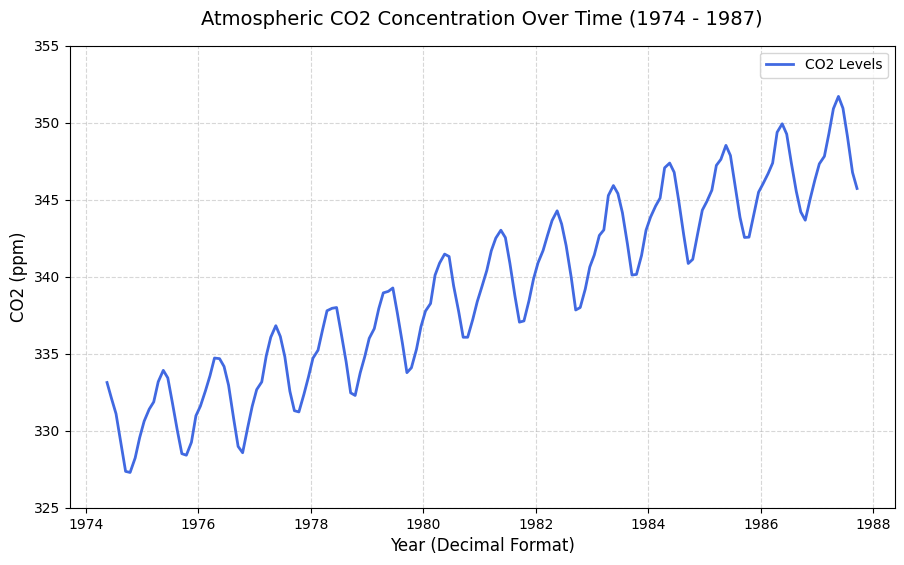

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import io

# 1. The Raw Data (Included inside the cell so it never gets lost)
raw_data = """
CO2        Year&Month      Year        Month
  333.13        1974.38        1974          5
  332.09        1974.46        1974          6
  331.10        1974.54        1974          7
  329.14        1974.63        1974          8
  327.36        1974.71        1974          9
  327.29        1974.79        1974         10
  328.23        1974.88        1974         11
  329.55        1974.96        1974         12
  330.62        1975.04        1975          1
  331.40        1975.13        1975          2
  331.87        1975.21        1975          3
  333.18        1975.29        1975          4
  333.92        1975.38        1975          5
  333.43        1975.46        1975          6
  331.85        1975.54        1975          7
  330.01        1975.63        1975          8
  328.51        1975.71        1975          9
  328.41        1975.79        1975         10
  329.25        1975.88        1975         11
  330.97        1975.96        1975         12
  331.60        1976.04        1976          1
  332.60        1976.13        1976          2
  333.57        1976.21        1976          3
  334.72        1976.29        1976          4
  334.68        1976.38        1976          5
  334.17        1976.46        1976          6
  332.96        1976.54        1976          7
  330.80        1976.63        1976          8
  328.98        1976.71        1976          9
  328.57        1976.79        1976         10
  330.20        1976.88        1976         11
  331.58        1976.96        1976         12
  332.67        1977.04        1977          1
  333.17        1977.13        1977          2
  334.86        1977.21        1977          3
  336.07        1977.29        1977          4
  336.82        1977.38        1977          5
  336.12        1977.46        1977          6
  334.81        1977.54        1977          7
  332.56        1977.63        1977          8
  331.30        1977.71        1977          9
  331.22        1977.79        1977         10
  332.37        1977.88        1977         11
  333.49        1977.96        1977         12
  334.71        1978.04        1978          1
  335.23        1978.13        1978          2
  336.54        1978.21        1978          3
  337.79        1978.29        1978          4
  337.95        1978.38        1978          5
  338.00        1978.46        1978          6
  336.37        1978.54        1978          7
  334.47        1978.63        1978          8
  332.46        1978.71        1978          9
  332.29        1978.79        1978         10
  333.76        1978.88        1978         11
  334.80        1978.96        1978         12
  336.00        1979.04        1979          1
  336.63        1979.13        1979          2
  337.93        1979.21        1979          3
  338.95        1979.29        1979          4
  339.05        1979.38        1979          5
  339.27        1979.46        1979          6
  337.64        1979.54        1979          7
  335.68        1979.63        1979          8
  333.77        1979.71        1979          9
  334.09        1979.79        1979         10
  335.29        1979.88        1979         11
  336.76        1979.96        1979         12
  337.77        1980.04        1980          1
  338.26        1980.13        1980          2
  340.10        1980.21        1980          3
  340.88        1980.29        1980          4
  341.47        1980.38        1980          5
  341.31        1980.46        1980          6
  339.41        1980.54        1980          7
  337.74        1980.63        1980          8
  336.07        1980.71        1980          9
  336.07        1980.79        1980         10
  337.22        1980.88        1980         11
  338.38        1980.96        1980         12
  339.32        1981.04        1981          1
  340.41        1981.13        1981          2
  341.69        1981.21        1981          3
  342.51        1981.29        1981          4
  343.02        1981.38        1981          5
  342.54        1981.46        1981          6
  340.88        1981.54        1981          7
  338.75        1981.63        1981          8
  337.05        1981.71        1981          9
  337.13        1981.79        1981         10
  338.45        1981.88        1981         11
  339.85        1981.96        1981         12
  340.90        1982.04        1982          1
  341.70        1982.13        1982          2
  342.70        1982.21        1982          3
  343.65        1982.29        1982          4
  344.28        1982.38        1982          5
  343.42        1982.46        1982          6
  342.02        1982.54        1982          7
  339.97        1982.63        1982          8
  337.84        1982.71        1982          9
  338.00        1982.79        1982         10
  339.20        1982.88        1982         11
  340.63        1982.96        1982         12
  341.41        1983.04        1983          1
  342.68        1983.13        1983          2
  343.04        1983.21        1983          3
  345.27        1983.29        1983          4
  345.92        1983.38        1983          5
  345.40        1983.46        1983          6
  344.16        1983.54        1983          7
  342.11        1983.63        1983          8
  340.11        1983.71        1983          9
  340.15        1983.79        1983         10
  341.38        1983.88        1983         11
  343.02        1983.96        1983         12
  343.87        1984.04        1984          1
  344.59        1984.13        1984          2
  345.11        1984.21        1984          3
  347.07        1984.29        1984          4
  347.38        1984.38        1984          5
  346.78        1984.46        1984          6
  344.96        1984.54        1984          7
  342.71        1984.63        1984          8
  340.86        1984.71        1984          9
  341.13        1984.79        1984         10
  342.84        1984.88        1984         11
  344.32        1984.96        1984         12
  344.88        1985.04        1985          1
  345.62        1985.13        1985          2
  347.23        1985.21        1985          3
  347.62        1985.29        1985          4
  348.53        1985.38        1985          5
  347.87        1985.46        1985          6
  346.00        1985.54        1985          7
  343.86        1985.63        1985          8
  342.55        1985.71        1985          9
  342.57        1985.79        1985         10
  344.11        1985.88        1985         11
  345.49        1985.96        1985         12
  346.04        1986.04        1986          1
  346.70        1986.13        1986          2
  347.38        1986.21        1986          3
  349.38        1986.29        1986          4
  349.93        1986.38        1986          5
  349.26        1986.46        1986          6
  347.44        1986.54        1986          7
  345.55        1986.63        1986          8
  344.21        1986.71        1986          9
  343.67        1986.79        1986         10
  345.09        1986.88        1986         11
  346.27        1986.96        1986         12
  347.33        1987.04        1987          1
  347.82        1987.13        1987          2
  349.29        1987.21        1987          3
  350.91        1987.29        1987          4
  351.71        1987.38        1987          5
  350.94        1987.46        1987          6
  349.10        1987.54        1987          7
  346.77        1987.63        1987          8
  345.73        1987.71        1987          9
"""

# 2. Cleanly parse the dataframe
df = pd.read_csv(io.StringIO(raw_data.strip()), sep=r"\s+")
df.columns = df.columns.str.strip() # Strip hidden column spaces

# 3. Establish the figure object explicitly
fig, ax = plt.subplots(figsize=(11, 6))

# 4. Plot the line directly on the ax axis object
ax.plot(df["Year&Month"], df["CO2"], color="royalblue", linewidth=2, label="CO2 Levels")

# 5. Force the labels and styling directly on the axis
ax.set_title("Atmospheric CO2 Concentration Over Time (1974 - 1987)", fontsize=14, pad=15)
ax.set_xlabel("Year (Decimal Format)", fontsize=12)
ax.set_ylabel("CO2 (ppm)", fontsize=12)

# 6. Hardcode the y-axis ticks so they CANNOT be skipped or hidden
ax.set_yticks([325, 330, 335, 340, 345, 350, 355])
ax.set_ylim(325, 355)

# 7. Add grid lines and formatting safety rails
ax.grid(True, linestyle="--", alpha=0.5)
ax.legend()

# 8. Add clear margin space on the left to make sure the text has room
plt.subplots_adjust(left=0.15)

# 9. Render the final graph
plt.show()

In [2]:
# 1. Calculate the difference between the current month and the previous month
df["Trend_Diff"] = df["CO2"].diff(periods=1)

# 2. Print the first few rows to inspect the transformation
print(df[["Year", "Month", "CO2", "Trend_Diff"]].head(4))

   Year  Month     CO2  Trend_Diff
0  1974      5  333.13         NaN
1  1974      6  332.09       -1.04
2  1974      7  331.10       -0.99
3  1974      8  329.14       -1.96


In [3]:
# 1. Apply a 12-month difference to our already trend-diffed data
df["Seasonal_Trend_Diff"] = df["Trend_Diff"].diff(periods=12)

# 2. Print a slice of the data where the 12-month math actually kicks in
print(df[["Year", "Month", "CO2", "Trend_Diff", "Seasonal_Trend_Diff"]].iloc[10:15])

    Year  Month     CO2  Trend_Diff  Seasonal_Trend_Diff
10  1975      3  331.87        0.47                  NaN
11  1975      4  333.18        1.31                  NaN
12  1975      5  333.92        0.74                  NaN
13  1975      6  333.43       -0.49                 0.55
14  1975      7  331.85       -1.58                -0.59


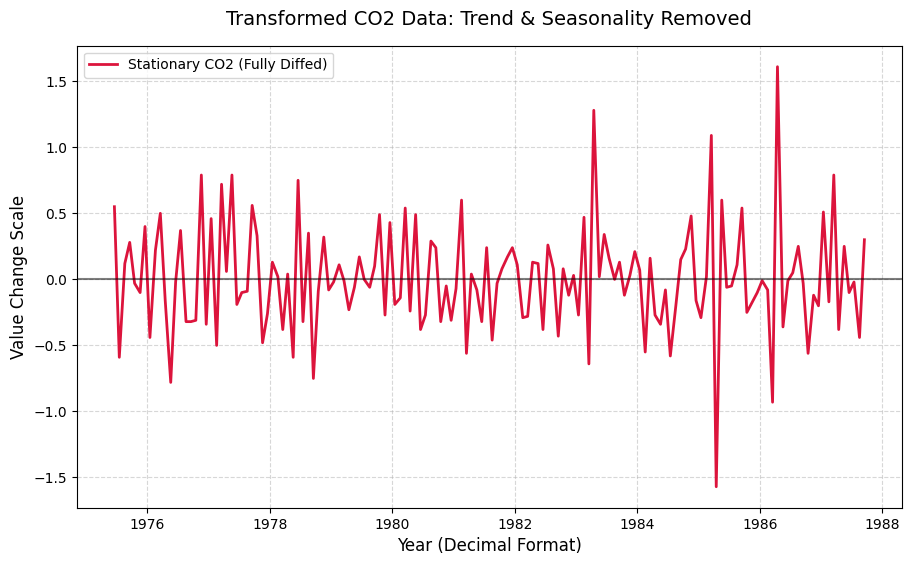

In [4]:
# 1. Create the figure canvas
fig, ax = plt.subplots(figsize=(11, 6))

# 2. Plot our fully transformed data column
ax.plot(df["Year&Month"], df["Seasonal_Trend_Diff"], color="crimson", linewidth=2, label="Stationary CO2 (Fully Diffed)")

# 3. Add titles and labels to explain the new view
ax.set_title("Transformed CO2 Data: Trend & Seasonality Removed", fontsize=14, pad=15)
ax.set_xlabel("Year (Decimal Format)", fontsize=12)
ax.set_ylabel("Value Change Scale", fontsize=12)

# 4. Add a solid baseline at 0 to see how well it centers
ax.axhline(0, color="black", linestyle="-", alpha=0.5)

# 5. Turn on grids and legends
ax.grid(True, linestyle="--", alpha=0.5)
ax.legend()

# 6. Adjust margins so it displays cleanly
plt.subplots_adjust(left=0.15)
plt.show()

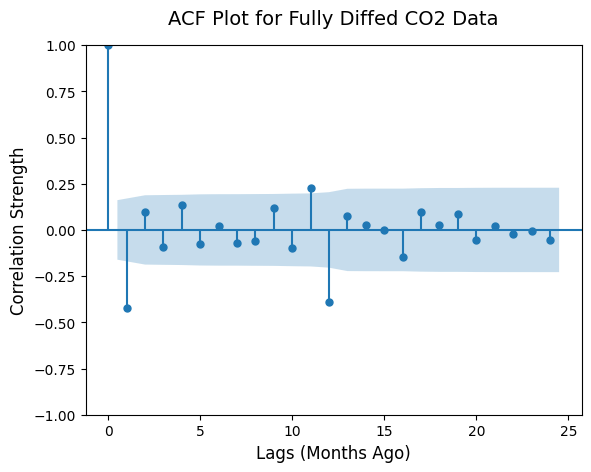

In [5]:
from statsmodels.graphics.tsaplots import plot_acf

# 1. Drop the blank rows from our column so the math runs cleanly
clean_diffed_data = df["Seasonal_Trend_Diff"].dropna()

# 2. Run the ACF plot function directly on your clean, flat data
# We look back 24 lags to see a full two-year window of past patterns
plot_acf(clean_diffed_data, lags=24)

# 3. Add titles and labels to your screen layout
plt.title("ACF Plot for Fully Diffed CO2 Data", fontsize=14, pad=15)
plt.xlabel("Lags (Months Ago)", fontsize=12)
plt.ylabel("Correlation Strength", fontsize=12)

# 4. Render the plot on your screen
plt.show()

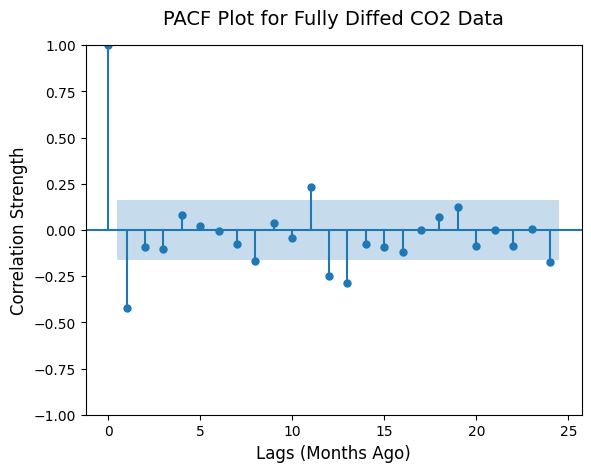

In [6]:
from statsmodels.graphics.tsaplots import plot_pacf

# 1. Drop the blank rows from our column so the math runs cleanly
clean_diffed_data = df["Seasonal_Trend_Diff"].dropna()

# 2. Run the PACF plot function directly on your clean, flat data
# We look back 24 lags to match your ACF view exactly
plot_pacf(clean_diffed_data, lags=24)

# 3. Add titles and labels to your screen layout
plt.title("PACF Plot for Fully Diffed CO2 Data", fontsize=14, pad=15)
plt.xlabel("Lags (Months Ago)", fontsize=12)
plt.ylabel("Correlation Strength", fontsize=12)

# 4. Render the plot on your screen
plt.show()

In [7]:
import pandas as pd

# 1. Combine the separate Year and Month columns into a single datetime index
# We assume the day is the 1st of the month ('MS') to keep it uniform
df.index = pd.to_datetime(df[['Year', 'Month']].assign(Day=1))

# 2. Explicitly tell Pandas that this index tracks continuous monthly data
df.index.freq = 'MS'

# 3. Re-create your clean data slice with the updated, healthy index
clean_diffed_data = df["Seasonal_Trend_Diff"].dropna()


In [8]:
from statsmodels.tsa.arima.model import ARIMA

# 1. Fit the AR(1) baseline model (p=1, d=0, q=0)
model_ar1 = ARIMA(clean_diffed_data, order=(1, 0, 0)).fit()

# 2. Fit the MA(1) baseline model (p=0, d=0, q=1)
model_ma1 = ARIMA(clean_diffed_data, order=(0, 0, 1)).fit()

# 3. Print the scorecard to see which one wins
print(f"AR(1) AIC Score: {model_ar1.aic}")
print(f"MA(1) AIC Score: {model_ma1.aic}")

AR(1) AIC Score: 133.07618626073418
MA(1) AIC Score: 132.61295919951908


In [9]:
from statsmodels.tsa.arima.model import ARIMA

# We fit the model on your raw CO2 column.
# ARIMA handles the math of trend and seasonal differencing for us automatically!
final_model = ARIMA(df["CO2"],
                    order=(0, 1, 1),
                    seasonal_order=(1, 1, 0, 12))

results = final_model.fit()
print(results.summary())

                                     SARIMAX Results                                     
Dep. Variable:                               CO2   No. Observations:                  161
Model:             ARIMA(0, 1, 1)x(1, 1, [], 12)   Log Likelihood                 -49.503
Date:                           Fri, 22 May 2026   AIC                            105.005
Time:                                   08:02:13   BIC                            113.997
Sample:                               05-01-1974   HQIC                           108.659
                                    - 09-01-1987                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.4524      0.071     -6.403      0.000      -0.591      -0.314
ar.S.L12      -0.4279      0.068     -6.303

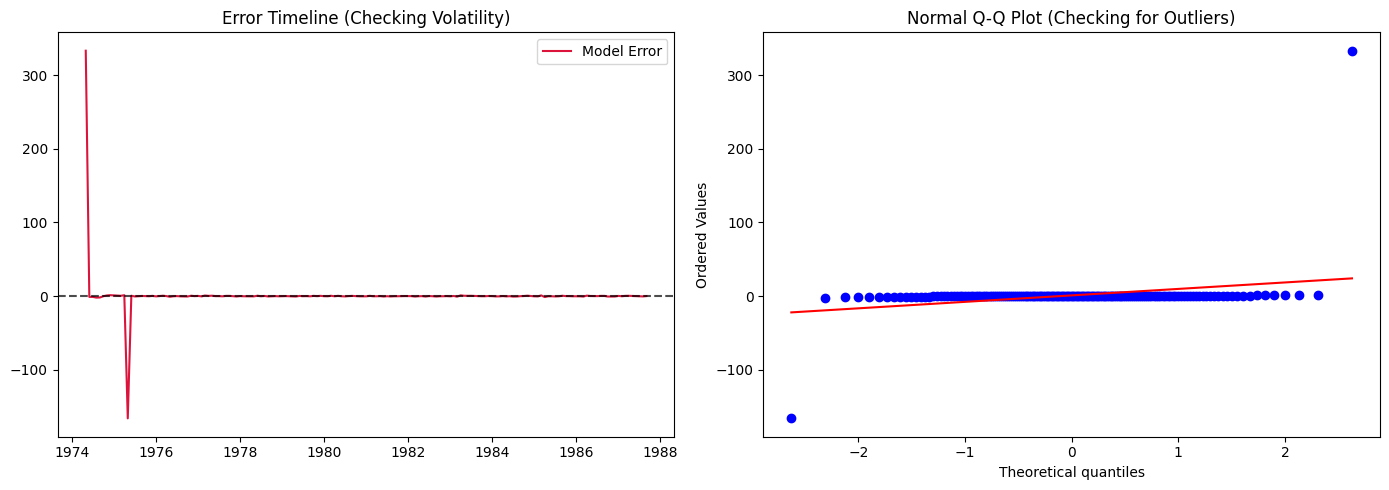

In [10]:
import matplotlib.pyplot as plt
import scipy.stats as stats

# 1. Extract the exact errors (residuals) from your fitted model
residuals = results.resid

# 2. Set up a clear 2-plot layout window
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot A: The Timeline View (To check consistency over time)
axes[0].plot(residuals, color='crimson', label='Model Error')
axes[0].axhline(0, color='black', linestyle='--', alpha=0.7)
axes[0].set_title("Error Timeline (Checking Volatility)")
axes[0].legend()

# Plot B: The Distribution Curve (To check the shape of the curve)
stats.probplot(residuals, dist="norm", plot=axes[1])
axes[1].set_title("Normal Q-Q Plot (Checking for Outliers)")

plt.tight_layout()
plt.show()

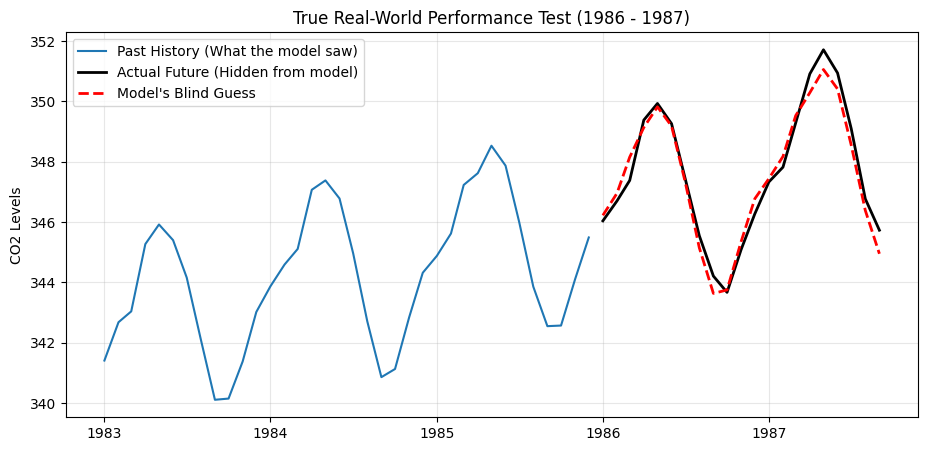

In [13]:
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA

# 1. Re-fit the model on the training data to guarantee it is in memory
train_model = ARIMA(train["CO2"], order=(0, 1, 1), seasonal_order=(1, 1, 0, 12))
train_results = train_model.fit()

# 2. Ask the model to predict the 21 months it has never seen
forecast = train_results.forecast(steps=21)

# 3. Plot the results to visually grade your model's accuracy
plt.figure(figsize=(11, 5))

# Plot the training history (the last 3 years of history for context)
plt.plot(train["CO2"].tail(36), label="Past History (What the model saw)")

# Plot the true values for 1986 and 1987
plt.plot(test["CO2"], label="Actual Future (Hidden from model)", color="black", linewidth=2)

# Plot the model's predictions
plt.plot(forecast, label="Model's Blind Guess", color="red", linestyle="--", linewidth=2)

plt.title("True Real-World Performance Test (1986 - 1987)")
plt.ylabel("CO2 Levels")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [14]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

# 1. Calculate the actual mathematical distance metrics
mae = mean_absolute_error(test["CO2"], forecast)
rmse = np.sqrt(mean_squared_error(test["CO2"], forecast))

# 2. Print the final accuracy scorecard
print("=== True Accuracy Scorecard ===")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")

=== True Accuracy Scorecard ===
Mean Absolute Error (MAE): 0.3711
Root Mean Squared Error (RMSE): 0.4338
